In [ ]:
%pip install pandas openpyxl matplotlib seaborn vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import re

df= pd.read_csv("data/raw_data_before_cleaning.csv")
df.head()

,Comment,Date,Platform
0,Great opportunity,2025-02-03,LinkedIn
1,I highly recommend,2025-05-04,LinkedIn
2,Amazing opportunity,2025-05-05,LinkedIn
3,Love this,2025-06-06,LinkedIn
4,Impressive,2025-02-07,LinkedIn


In [9]:
df["Date"] = pd.to_datetime(df["Date"])

print(f"✅ Saved {len(df)} records to raw_data.xlsx")
print(df["Platform"].value_counts())

✅ Saved 51 records to raw_data.xlsx
Platform
Website           25
LinkedIn          10
Google Reviews     7
Facebook           5
Instagram          4
Name: count, dtype: int64


In [7]:
df.tail()

,Comment,Date,Platform
46,Their customer service leaves a lot to be desi...,2025-10-15,Facebook
47,Just got placed by Gamage Recruiters into an a...,2025-07-05,Instagram
48,Mixed feelings. The job I was placed in didn't...,2025-07-25,Instagram
49,Gamage Recruiters is amazing! They truly under...,2025-08-10,Instagram
50,"Quick, efficient, and professional. Gamage Rec...",2025-11-01,Instagram


In [10]:
print(f"Before cleaning: {len(df)} records")
print(f"Duplicates found: {df.duplicated(subset='Comment').sum()}")


Before cleaning: 51 records
Duplicates found: 0


In [16]:
# ── Cleaning Function ──────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r"http\\S+|www\\S+", "", text)        # remove URLs
    text = re.sub(r"@\\w+|#\\w+", "", text)             # remove @mentions #hashtags
    text = re.sub(r"[^\\w\\s]", " ", text)              # remove punctuation
    text = re.sub(r"\\s+", " ", text).strip()          # remove extra spaces
    return text

In [18]:
# Apply cleaning
df["Cleaned_Comment"] = df["Comment"].apply(clean_text)

In [19]:
# Remove duplicates & empty rows
df.drop_duplicates(subset="Cleaned_Comment", inplace=True)
df.dropna(subset=["Cleaned_Comment"], inplace=True)
df = df[df["Cleaned_Comment"].str.len() > 3]
df.reset_index(drop=True, inplace=True)

print(f"After cleaning: {len(df)} records")


After cleaning: 45 records


In [20]:
df.head()

,Comment,Date,Platform,Cleaned_Comment
0,Gamage Recruiters is one of the most professio...,2025-07-10,LinkedIn,s s s ss ...
1,Not satisfied with the response time. Took wee...,2025-08-15,LinkedIn,s s w s s w s
2,Outstanding support from the team. They truly ...,2025-09-01,LinkedIn,s s
3,Very helpful and responsive team. Streamlined ...,2025-09-20,LinkedIn,s s s ...
4,I've had the privilege of working with Gamage ...,2025-06-09,Website,w w s s ...


In [21]:
# Save cleaned data
df.to_csv("cleaned_data.csv", index=False)
print("✅ Saved cleaned_data.csv")

# Preview side by side
print("\\n── Sample Before vs After ──────────────────────────")
for i in range(3):
    print(f"\\nORIGINAL : {df['Comment'].iloc[i]}")
    print(f"CLEANED  : {df['Cleaned_Comment'].iloc[i]}")

✅ Saved cleaned_data.csv
\n── Sample Before vs After ──────────────────────────
\nORIGINAL : Gamage Recruiters is one of the most professional recruitment agencies I have worked with. Their attention to detail and candidate matching is exceptional.
CLEANED  : s  s              s       ss                         s        w      w                                                       s
\nORIGINAL : Not satisfied with the response time. Took weeks to hear back after applying.
CLEANED  : s   s     w          s   s             w   s
\nORIGINAL : Outstanding support from the team. They truly care about finding the right fit.
CLEANED  : s        s


Sentiment Analysis

In [22]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load cleaned data
df = pd.read_csv("cleaned_data.csv")

# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

# ── Sentiment Function ─────────────────────────────────────────
def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores["compound"]

    if compound >= 0.05:
        label = "Positive"
    elif compound <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"

    return label, round(compound, 4)

# Apply to every row
df[["Sentiment", "Compound_Score"]] = df["Cleaned_Comment"].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Save labeled data
df.to_csv("sentiment_labeled.csv", index=False)
print("✅ Saved sentiment_labeled.csv")
print(f"\\nSentiment Distribution:")
print(df["Sentiment"].value_counts())
print(f"\\nSample scores:")
print(df[["Comment","Sentiment","Compound_Score"]].head(5).to_string())

✅ Saved sentiment_labeled.csv
\nSentiment Distribution:
Sentiment
Neutral    45
Name: count, dtype: int64
\nSample scores:
                                                                                                                                                                                                                                                                                                                                                                                                                 Comment Sentiment  Compound_Score
0                                                                                                                                                                                                                                                            Gamage Recruiters is one of the most professional recruitment agencies I have worked with. Their attention to detail and candidate matching is exceptional.   Neutral             0.0
1      

In [23]:
import pandas as pd

df = pd.read_csv("sentiment_labeled.csv")

# ── Overall distribution ───────────────────────────────────────
counts = df["Sentiment"].value_counts().reset_index()
counts.columns = ["Sentiment", "Count"]
counts["Percentage"] = (counts["Count"] / len(df) * 100).round(1).astype(str) + "%"
print("Overall Sentiment:")
print(counts.to_string(index=False))

# ── By Platform ────────────────────────────────────────────────
by_platform = df.groupby(["Platform","Sentiment"]).size().unstack(fill_value=0)
print("\\nBy Platform:")
print(by_platform)

# ── By Month ───────────────────────────────────────────────────
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M").astype(str)
by_month = df.groupby(["Month","Sentiment"]).size().unstack(fill_value=0)
print("\\nBy Month:")
print(by_month)

# Save
counts.to_csv("summary_stats.csv", index=False)
by_platform.to_csv("platform_breakdown.csv")
by_month.to_csv("monthly_trend.csv")
print("\\n✅ Saved summary_stats.csv, platform_breakdown.csv, monthly_trend.csv")

Overall Sentiment:
Sentiment  Count Percentage
  Neutral     45     100.0%
\nBy Platform:
Sentiment       Neutral
Platform               
Facebook              5
Google Reviews        7
Instagram             4
LinkedIn              4
Website              25
\nBy Month:
Sentiment  Neutral
Month             
2025-06         20
2025-07          3
2025-08          4
2025-09          4
2025-10          3
2025-11          3
2025-12          2
2026-01          1
2026-02          5
\n✅ Saved summary_stats.csv, platform_breakdown.csv, monthly_trend.csv


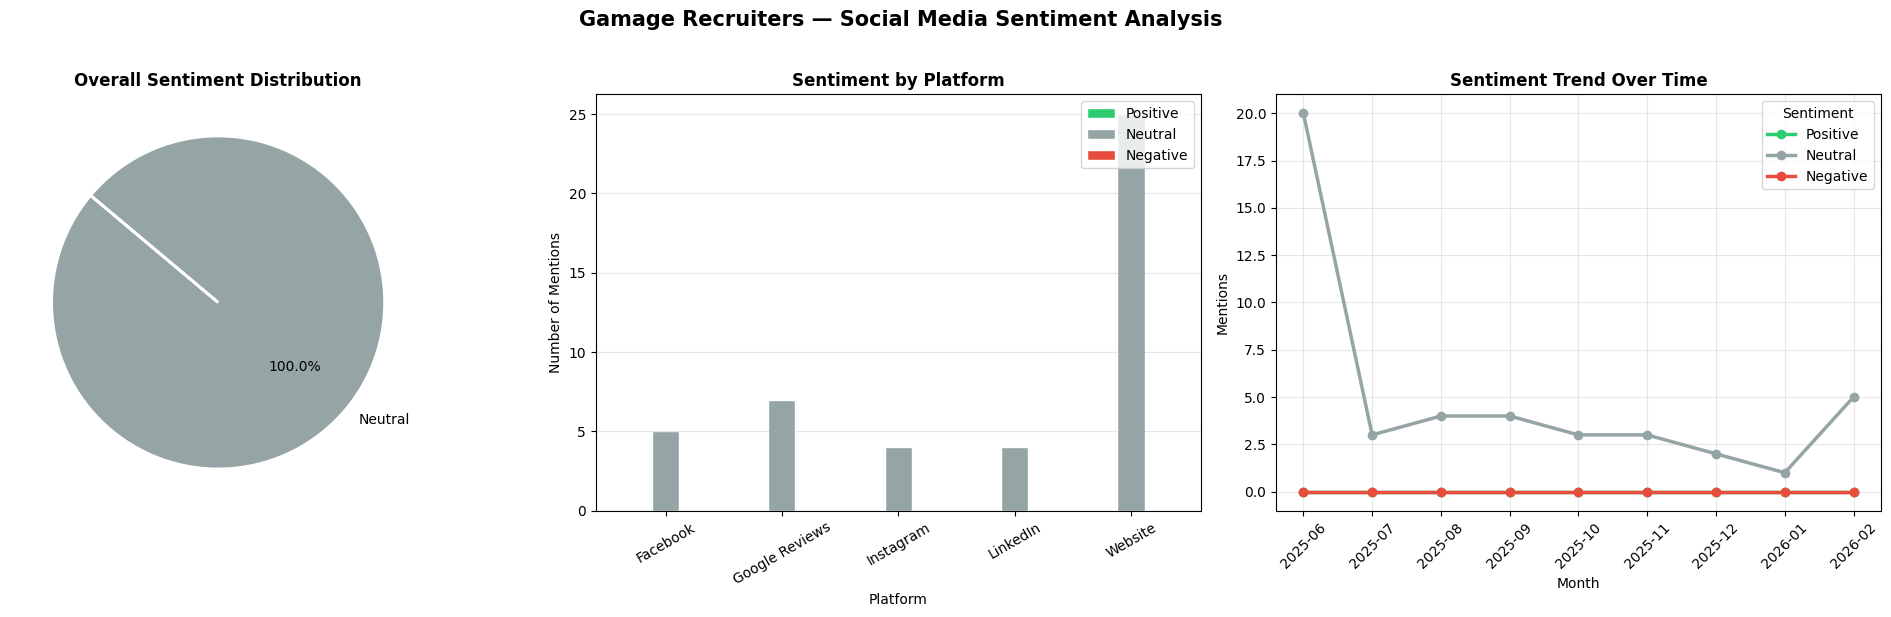

✅ Saved charts.png


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df       = pd.read_csv("sentiment_labeled.csv")
counts   = df["Sentiment"].value_counts()
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M").astype(str)

COLORS = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Gamage Recruiters — Social Media Sentiment Analysis",
             fontsize=15, fontweight="bold", y=1.02)

# ── Chart 1: Pie Chart ─────────────────────────────────────────
colors_pie = [COLORS[s] for s in counts.index]
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=colors_pie, startangle=140,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[0].set_title("Overall Sentiment Distribution", fontweight="bold")

# ── Chart 2: Bar Chart by Platform ────────────────────────────
by_platform = df.groupby(["Platform","Sentiment"]).size().unstack(fill_value=0)
for col in ["Positive","Neutral","Negative"]:
    if col not in by_platform: by_platform[col] = 0
by_platform[["Positive","Neutral","Negative"]].plot(
    kind="bar", ax=axes[1],
    color=[COLORS["Positive"], COLORS["Neutral"], COLORS["Negative"]],
    edgecolor="white", width=0.7)
axes[1].set_title("Sentiment by Platform", fontweight="bold")
axes[1].set_xlabel("Platform")
axes[1].set_ylabel("Number of Mentions")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="upper right")
axes[1].grid(axis="y", alpha=0.3)

# ── Chart 3: Line Chart Trend ─────────────────────────────────
trend = df.groupby(["Month","Sentiment"]).size().unstack(fill_value=0)
for col in ["Positive","Neutral","Negative"]:
    if col not in trend: trend[col] = 0
trend[["Positive","Neutral","Negative"]].plot(
    ax=axes[2],
    color=[COLORS["Positive"], COLORS["Neutral"], COLORS["Negative"]],
    marker="o", linewidth=2.5, markersize=6)
axes[2].set_title("Sentiment Trend Over Time", fontweight="bold")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Mentions")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("charts.png", dpi=180, bbox_inches="tight")
plt.show()
print("✅ Saved charts.png")

In [25]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image

df          = pd.read_csv("sentiment_labeled.csv")
counts      = df["Sentiment"].value_counts()
pct         = df["Sentiment"].value_counts(normalize=True).mul(100).round(1)
by_platform = df.groupby(["Platform","Sentiment"]).size().unstack(fill_value=0)

wb  = Workbook()
HDR = "1F3864"
FILLS = {
    "Positive": PatternFill("solid", start_color="C6EFCE"),
    "Neutral":  PatternFill("solid", start_color="FFEB9C"),
    "Negative": PatternFill("solid", start_color="FFC7CE"),
}

def style_header(cell, text):
    cell.value     = text
    cell.font      = Font(name="Arial", bold=True, color="FFFFFF", size=11)
    cell.fill      = PatternFill("solid", start_color=HDR)
    cell.alignment = Alignment(horizontal="center", vertical="center")

def thin_border():
    s = Side(style="thin", color="CCCCCC")
    return Border(left=s, right=s, top=s, bottom=s)

# ── Sheet 1: Labeled Data ─────────────────────────────────────
ws1 = wb.active
ws1.title = "Labeled Data"
ws1.freeze_panes = "A2"
headers = ["#","Original Comment","Date","Platform","Cleaned Comment","Sentiment","Score"]
widths  = [5, 60, 14, 16, 55, 12, 10]
for i,(h,w) in enumerate(zip(headers,widths),1):
    style_header(ws1.cell(1,i), h)
    ws1.column_dimensions[get_column_letter(i)].width = w

for idx, row in df.iterrows():
    r = idx + 2
    vals = [idx+1, row["Comment"], row["Date"], row["Platform"],
            row["Cleaned_Comment"], row["Sentiment"], row["Compound_Score"]]
    for c, v in enumerate(vals, 1):
        cell = ws1.cell(r, c, v)
        cell.font      = Font(name="Arial", size=10)
        cell.border    = thin_border()
        cell.alignment = Alignment(vertical="top", wrap_text=(c in [2,5]))
        if c == 6:
            cell.fill = FILLS.get(row["Sentiment"], PatternFill())
            cell.font = Font(name="Arial", size=10, bold=True)
    ws1.row_dimensions[r].height = 35

# ── Sheet 2: Summary ──────────────────────────────────────────
ws2 = wb.create_sheet("Summary")
ws2.merge_cells("A1:C1")
style_header(ws2["A1"], "Gamage Recruiters — Sentiment Summary")
ws2.row_dimensions[1].height = 28

for i,(h,w) in enumerate(zip(["Sentiment","Count","Percentage (%)"], [18,12,18]),1):
    style_header(ws2.cell(3,i), h)
    ws2.column_dimensions[get_column_letter(i)].width = w

for i, s in enumerate(["Positive","Neutral","Negative"], 4):
    ws2.cell(i,1,s).fill  = FILLS[s]
    ws2.cell(i,2, int(counts.get(s,0)))
    ws2.cell(i,3, f"{pct.get(s,0)}%")
    for c in range(1,4):
        ws2.cell(i,c).font      = Font(name="Arial", size=10, bold=(c==1))
        ws2.cell(i,c).border    = thin_border()
        ws2.cell(i,c).alignment = Alignment(horizontal="center")

ws2.cell(7,1,"Total").font = Font(bold=True, name="Arial")
ws2.cell(7,2,f"=SUM(B4:B6)")
ws2.cell(7,3,"100%")
for c in range(1,4):
    ws2.cell(7,c).border    = thin_border()
    ws2.cell(7,c).alignment = Alignment(horizontal="center")

# ── Sheet 3: Charts ───────────────────────────────────────────
ws3 = wb.create_sheet("Charts")
ws3.merge_cells("A1:B1")
style_header(ws3["A1"], "Sentiment Visualizations")
ws3.row_dimensions[1].height = 24
img = Image("charts.png")
img.width  = 900
img.height = 280
ws3.add_image(img, "A3")

wb.save("sentiment_report.xlsx")
print("✅ Saved sentiment_report.xlsx")

✅ Saved sentiment_report.xlsx
